In [1]:
import pandas as pd
chunks = pd.read_csv(
    "flights.csv",
    chunksize=200000,
    low_memory=False,
    dtype={
        'ORIGIN_AIRPORT': str,
        'DESTINATION_AIRPORT': str
    }
)

df = pd.concat(chunks, ignore_index=True)
df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 31 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   YEAR                 1048575 non-null  int64  
 1   MONTH                1048575 non-null  int64  
 2   DAY                  1048575 non-null  int64  
 3   DAY_OF_WEEK          1048575 non-null  int64  
 4   AIRLINE              1048575 non-null  object 
 5   FLIGHT_NUMBER        1048575 non-null  int64  
 6   TAIL_NUMBER          1040825 non-null  object 
 7   ORIGIN_AIRPORT       1048575 non-null  object 
 8   DESTINATION_AIRPORT  1048575 non-null  object 
 9   SCHEDULED_DEPARTURE  1048575 non-null  int64  
 10  DEPARTURE_TIME       1009060 non-null  float64
 11  DEPARTURE_DELAY      1009060 non-null  float64
 12  TAXI_OUT             1008346 non-null  float64
 13  WHEELS_OFF           1008346 non-null  float64
 14  SCHEDULED_TIME       1048573 non-null  float64
 15

In [3]:
df.isnull().sum().sort_values(ascending=False)

CANCELLATION_REASON    1008048
WEATHER_DELAY           820047
LATE_AIRCRAFT_DELAY     820047
AIRLINE_DELAY           820047
SECURITY_DELAY          820047
AIR_SYSTEM_DELAY        820047
AIR_TIME                 43071
ARRIVAL_DELAY            43071
ELAPSED_TIME             43071
WHEELS_ON                41296
TAXI_IN                  41296
ARRIVAL_TIME             41296
TAXI_OUT                 40229
WHEELS_OFF               40229
DEPARTURE_DELAY          39515
DEPARTURE_TIME           39515
TAIL_NUMBER               7750
SCHEDULED_TIME               2
SCHEDULED_DEPARTURE          0
CANCELLED                    0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
FLIGHT_NUMBER                0
SCHEDULED_ARRIVAL            0
DIVERTED                     0
ORIGIN_AIRPORT               0
DISTANCE                     0
DESTINATION_AIRPORT          0
MONTH                        0
YEAR                         0
dtype: int64

In [4]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent.sort_values(ascending=False)

CANCELLATION_REASON    96.135040
WEATHER_DELAY          78.205851
LATE_AIRCRAFT_DELAY    78.205851
AIRLINE_DELAY          78.205851
SECURITY_DELAY         78.205851
AIR_SYSTEM_DELAY       78.205851
AIR_TIME                4.107575
ARRIVAL_DELAY           4.107575
ELAPSED_TIME            4.107575
WHEELS_ON               3.938297
TAXI_IN                 3.938297
ARRIVAL_TIME            3.938297
TAXI_OUT                3.836540
WHEELS_OFF              3.836540
DEPARTURE_DELAY         3.768448
DEPARTURE_TIME          3.768448
TAIL_NUMBER             0.739098
SCHEDULED_TIME          0.000191
SCHEDULED_DEPARTURE     0.000000
CANCELLED               0.000000
DAY                     0.000000
DAY_OF_WEEK             0.000000
AIRLINE                 0.000000
FLIGHT_NUMBER           0.000000
SCHEDULED_ARRIVAL       0.000000
DIVERTED                0.000000
ORIGIN_AIRPORT          0.000000
DISTANCE                0.000000
DESTINATION_AIRPORT     0.000000
MONTH                   0.000000
YEAR      

In [5]:
%pip install missingno

Note: you may need to restart the kernel to use updated packages.


<Axes: >

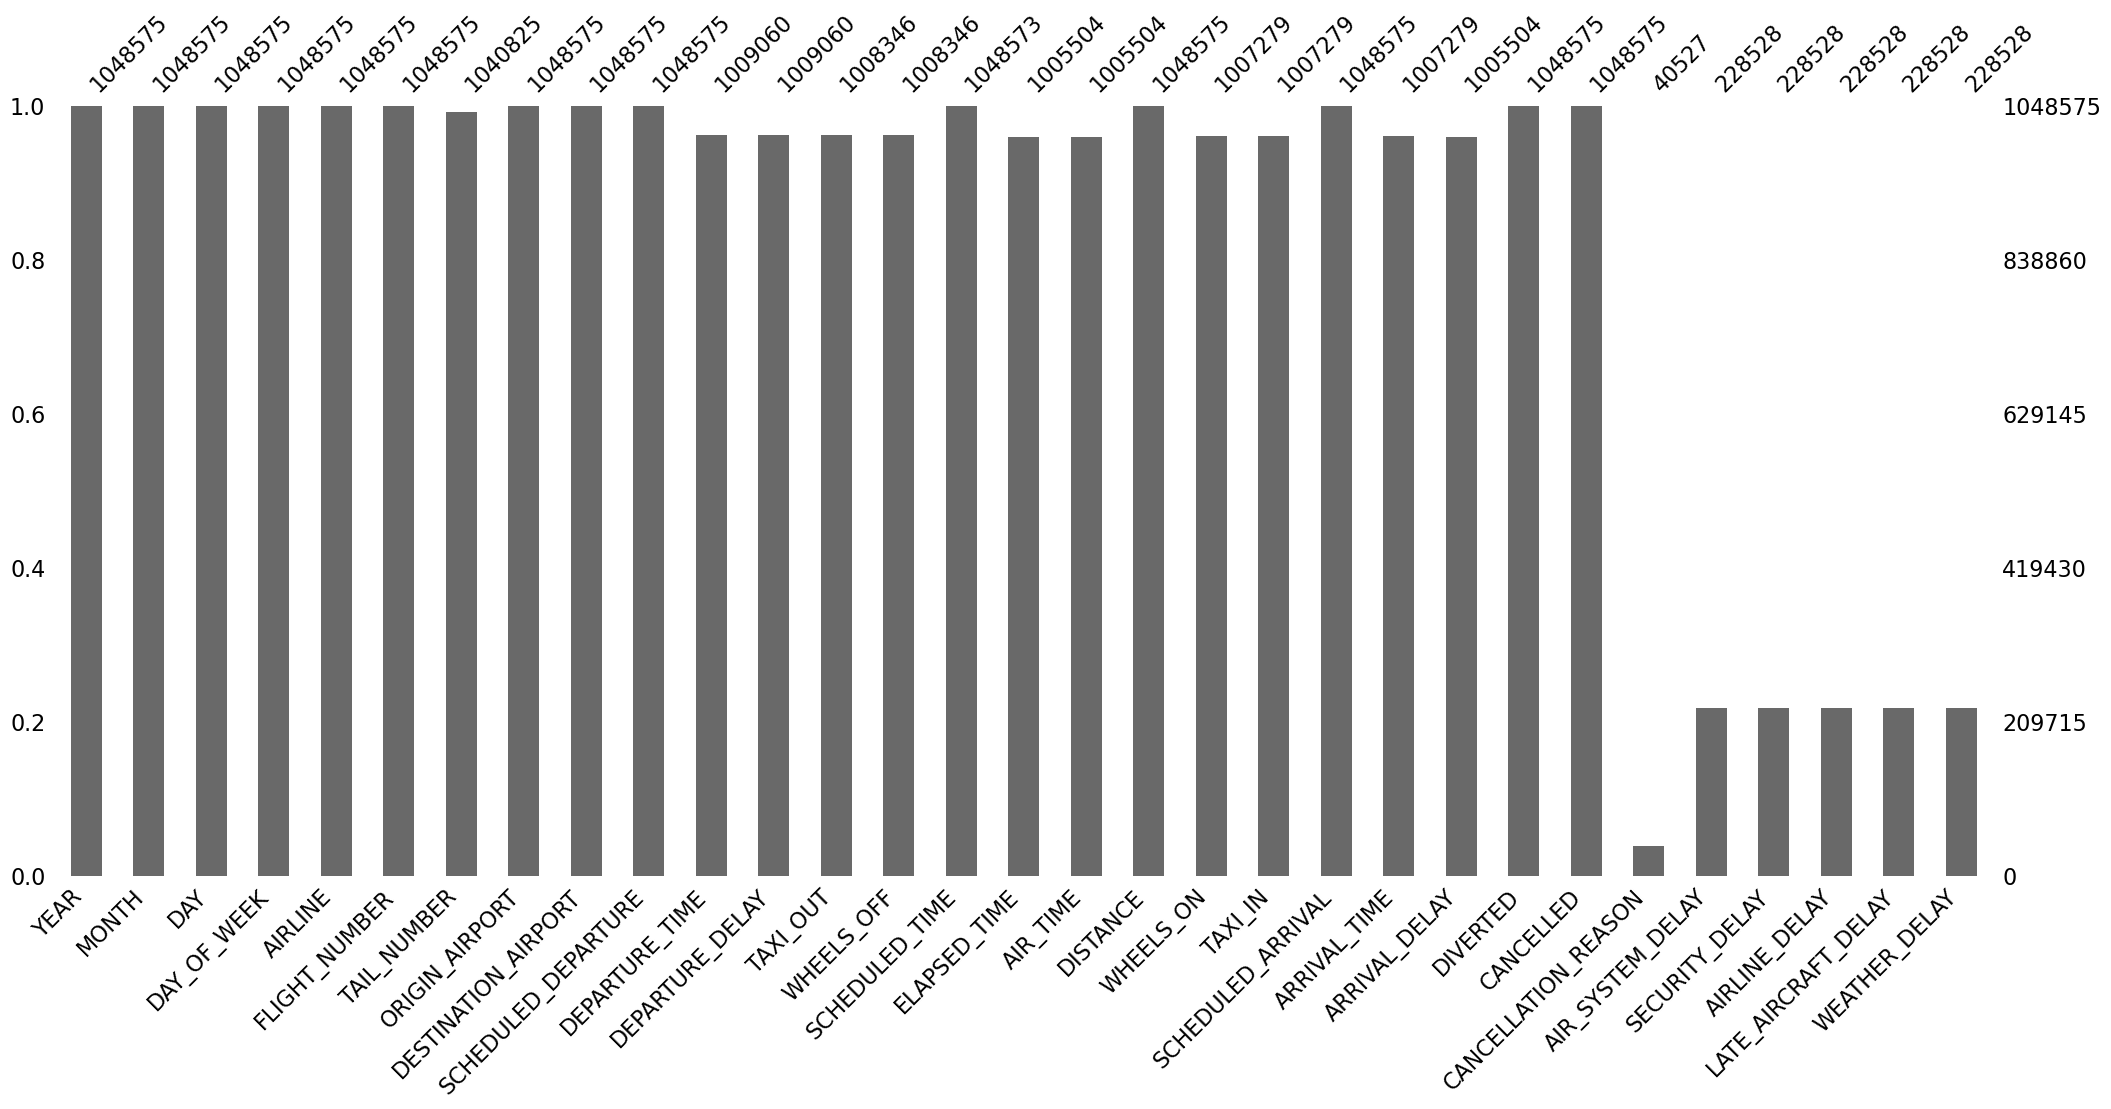

In [6]:
import missingno as msno

msno.bar(df)

In [7]:
df['CANCELLATION_REASON'] = df['CANCELLATION_REASON'].fillna("None")

In [8]:
delay_cols = [
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY'
]

df[delay_cols] = df[delay_cols].fillna(0)

In [9]:
df['DEPARTURE_DELAY'] = df['DEPARTURE_DELAY'].fillna(0)
df['ARRIVAL_DELAY'] = df['ARRIVAL_DELAY'].fillna(0)

In [10]:
day_map = {
    1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu",
    5: "Fri", 6: "Sat", 7: "Sun"
}

df['DAY_NAME'] = df['DAY_OF_WEEK'].map(day_map)

In [11]:
df['DEP_HOUR'] = df['SCHEDULED_DEPARTURE'] // 100

In [12]:
df['ROUTE'] = df['ORIGIN_AIRPORT'] + " → " + df['DESTINATION_AIRPORT']

In [13]:
month_map = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

df['MONTH_NAME'] = df['MONTH'].map(month_map)

In [14]:
df.isnull().sum()

YEAR                       0
MONTH                      0
DAY                        0
DAY_OF_WEEK                0
AIRLINE                    0
FLIGHT_NUMBER              0
TAIL_NUMBER             7750
ORIGIN_AIRPORT             0
DESTINATION_AIRPORT        0
SCHEDULED_DEPARTURE        0
DEPARTURE_TIME         39515
DEPARTURE_DELAY            0
TAXI_OUT               40229
WHEELS_OFF             40229
SCHEDULED_TIME             2
ELAPSED_TIME           43071
AIR_TIME               43071
DISTANCE                   0
WHEELS_ON              41296
TAXI_IN                41296
SCHEDULED_ARRIVAL          0
ARRIVAL_TIME           41296
ARRIVAL_DELAY              0
DIVERTED                   0
CANCELLED                  0
CANCELLATION_REASON        0
AIR_SYSTEM_DELAY           0
SECURITY_DELAY             0
AIRLINE_DELAY              0
LATE_AIRCRAFT_DELAY        0
WEATHER_DELAY              0
DAY_NAME                   0
DEP_HOUR                   0
ROUTE                      0
MONTH_NAME    

In [15]:
df.to_csv("flights_cleaned_full.csv", index=False)

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

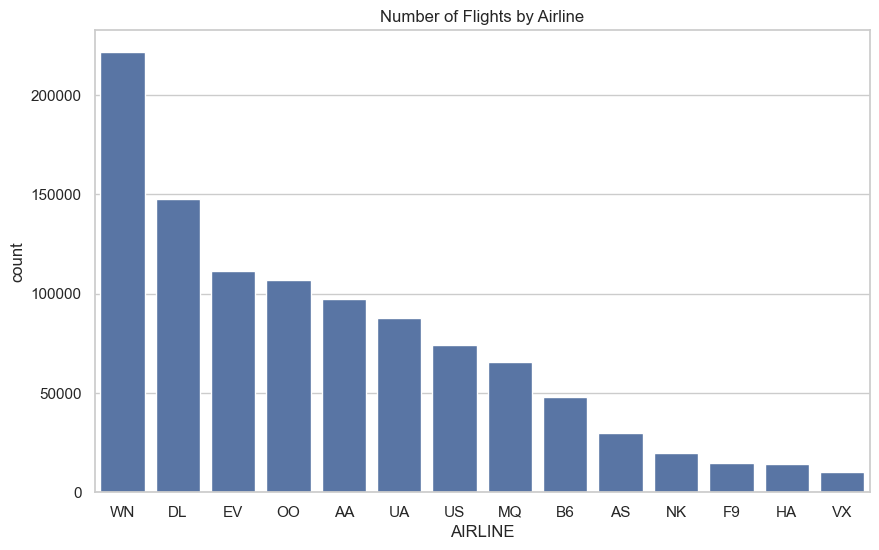

In [17]:
plt.figure(figsize=(10,6))
sns.countplot(x='AIRLINE', data=df, order=df['AIRLINE'].value_counts().index)
plt.title("Number of Flights by Airline")
plt.show()

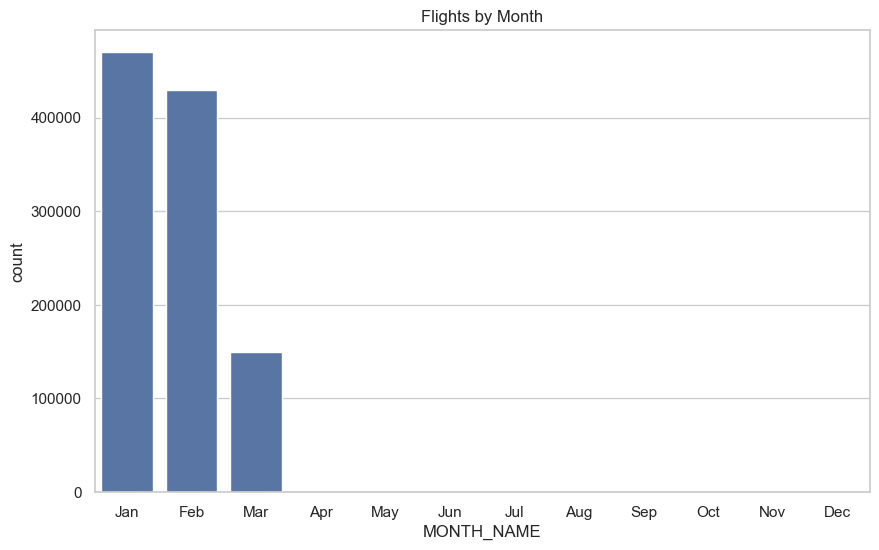

In [18]:
plt.figure(figsize=(10,6))
sns.countplot(x='MONTH_NAME', data=df,
              order=['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title("Flights by Month")
plt.show()

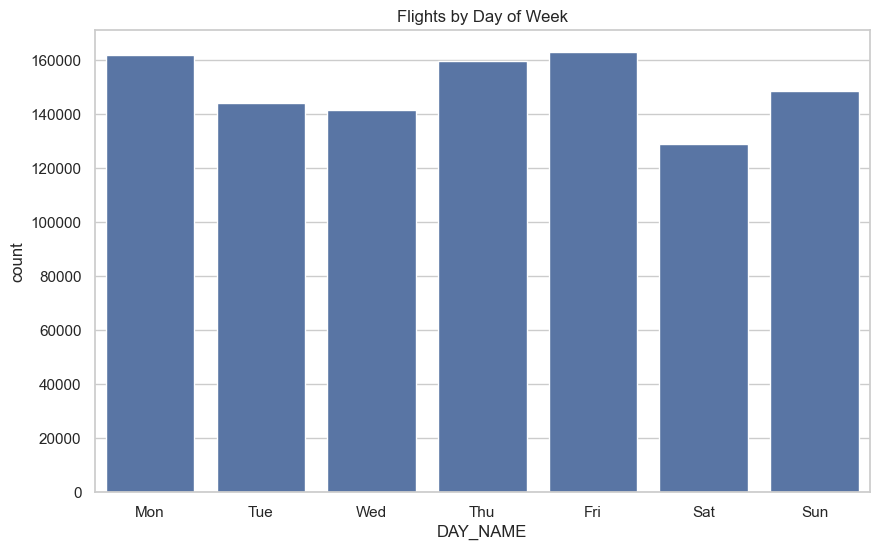

In [19]:
plt.figure(figsize=(10,6))
sns.countplot(x='DAY_NAME', data=df,
              order=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
plt.title("Flights by Day of Week")
plt.show()

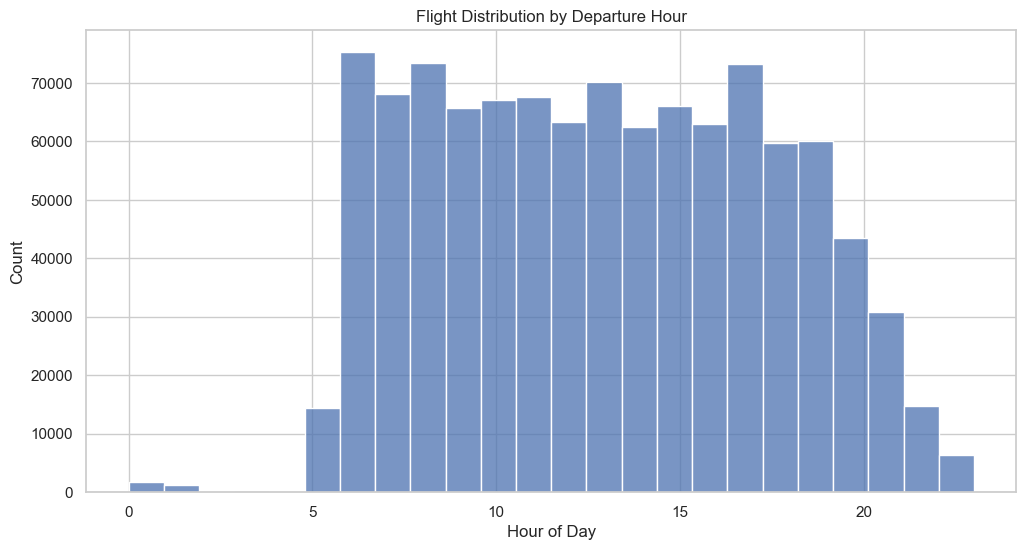

In [20]:
plt.figure(figsize=(12,6))
sns.histplot(df['DEP_HOUR'], bins=24, kde=False)
plt.title("Flight Distribution by Departure Hour")
plt.xlabel("Hour of Day")
plt.show()

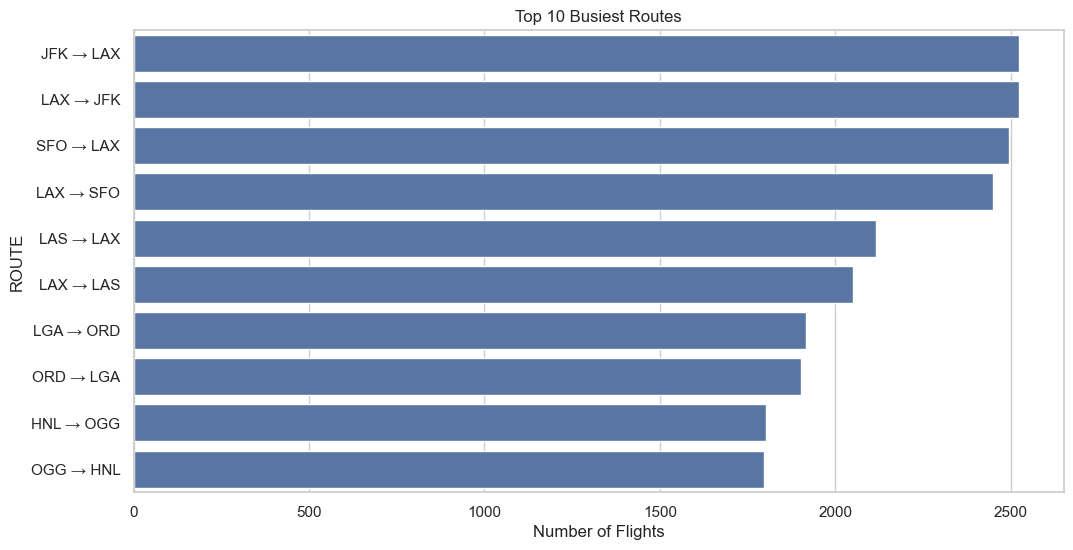

In [21]:
top_routes = df['ROUTE'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_routes.values, y=top_routes.index)
plt.title("Top 10 Busiest Routes")
plt.xlabel("Number of Flights")
plt.show()

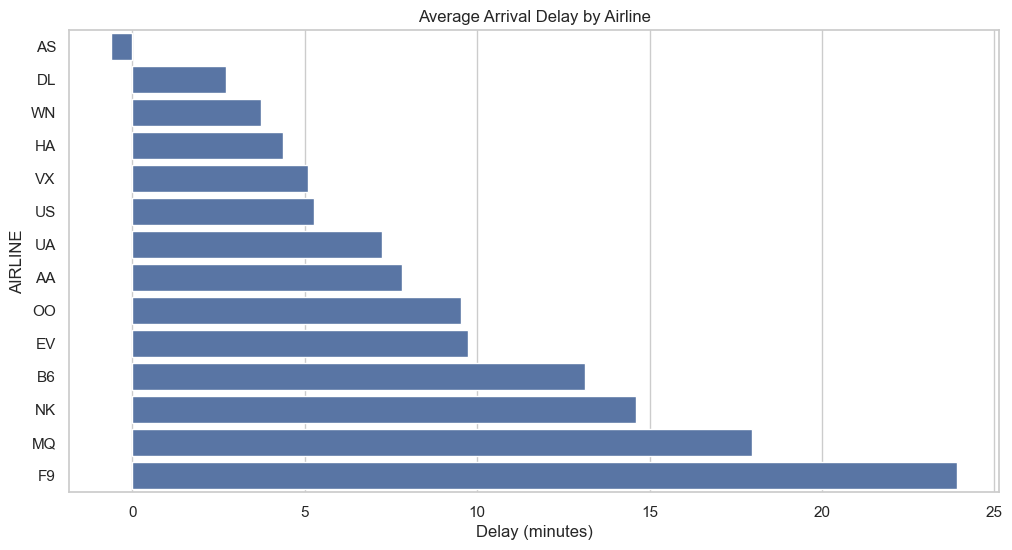

In [22]:
airline_delay = df.groupby('AIRLINE')['ARRIVAL_DELAY'].mean().sort_values()

plt.figure(figsize=(12,6))
sns.barplot(x=airline_delay.values, y=airline_delay.index)
plt.title("Average Arrival Delay by Airline")
plt.xlabel("Delay (minutes)")
plt.show()

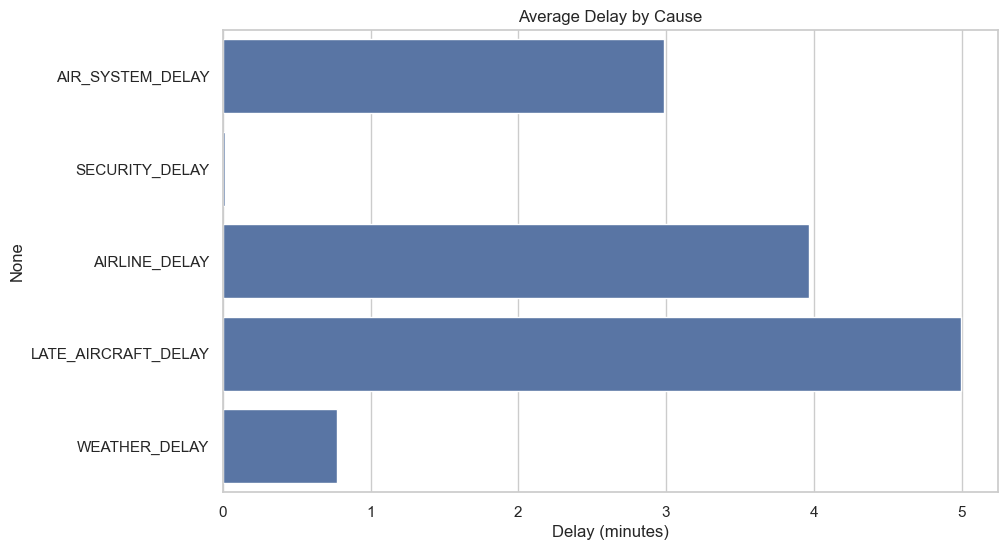

In [23]:
delay_causes = df[[
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY'
]].mean()

plt.figure(figsize=(10,6))
sns.barplot(x=delay_causes.values, y=delay_causes.index)
plt.title("Average Delay by Cause")
plt.xlabel("Delay (minutes)")
plt.show()

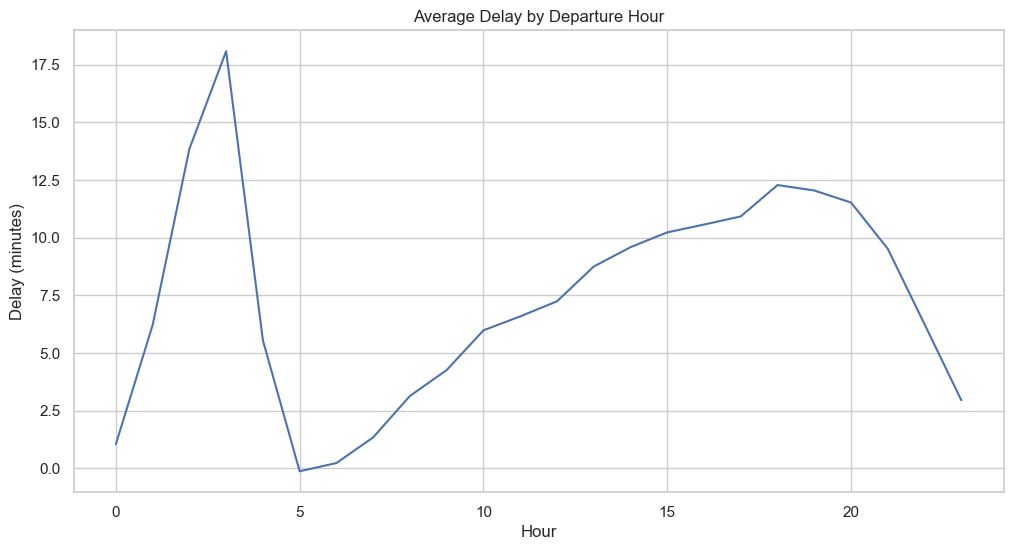

In [24]:
hour_delay = df.groupby('DEP_HOUR')['ARRIVAL_DELAY'].mean()

plt.figure(figsize=(12,6))
sns.lineplot(x=hour_delay.index, y=hour_delay.values)
plt.title("Average Delay by Departure Hour")
plt.xlabel("Hour")
plt.ylabel("Delay (minutes)")
plt.show()

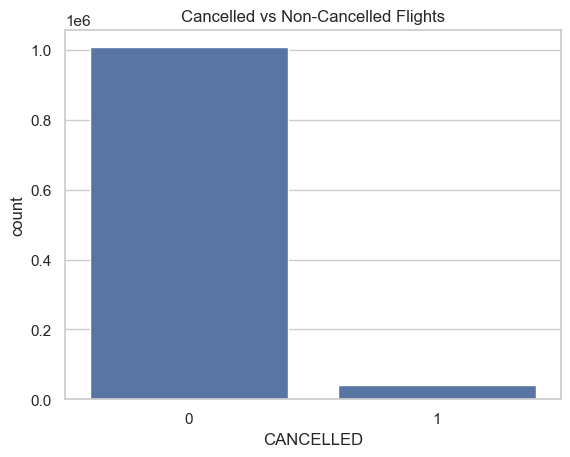

In [25]:
sns.countplot(x='CANCELLED', data=df)
plt.title("Cancelled vs Non-Cancelled Flights")
plt.show()

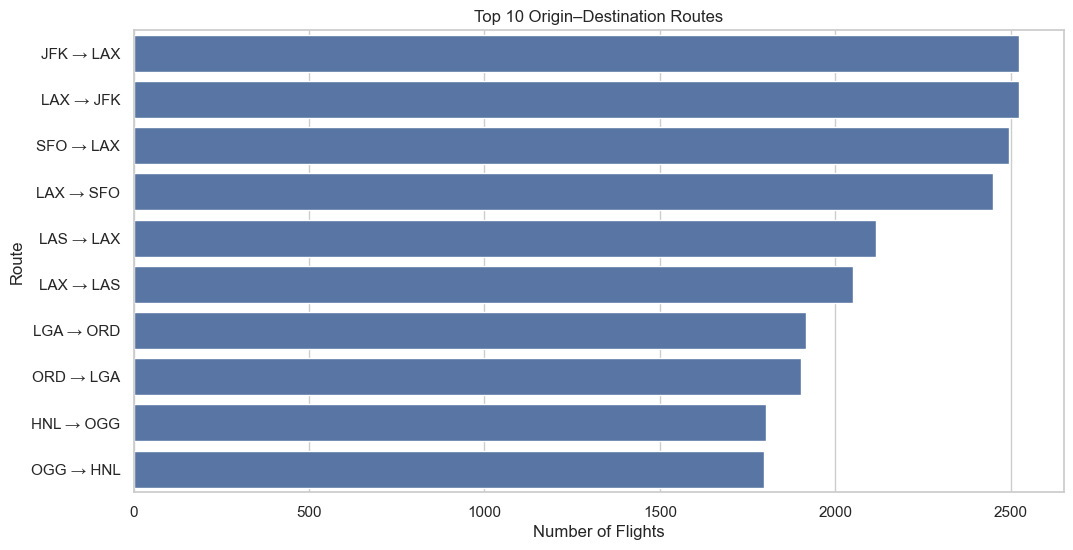

In [26]:
top_routes = df['ROUTE'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_routes.values, y=top_routes.index)
plt.title("Top 10 Origin–Destination Routes")
plt.xlabel("Number of Flights")
plt.ylabel("Route")
plt.show()

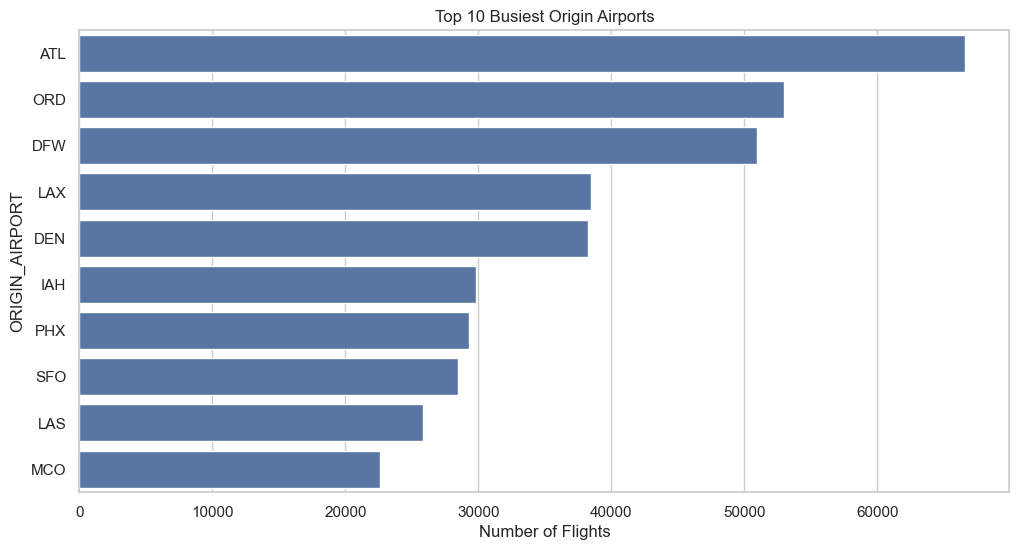

In [27]:
top_origin = df['ORIGIN_AIRPORT'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_origin.values, y=top_origin.index)
plt.title("Top 10 Busiest Origin Airports")
plt.xlabel("Number of Flights")
plt.show()

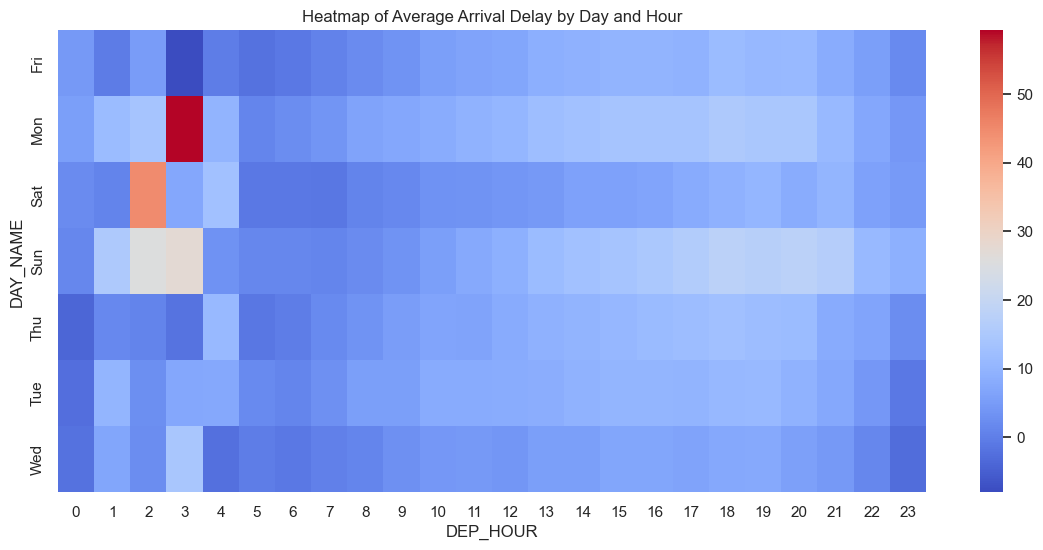

In [28]:
pivot_table = df.pivot_table(values='ARRIVAL_DELAY',
                             index='DAY_NAME',
                             columns='DEP_HOUR',
                             aggfunc='mean')

plt.figure(figsize=(14,6))
sns.heatmap(pivot_table, cmap="coolwarm")
plt.title("Heatmap of Average Arrival Delay by Day and Hour")
plt.show()

In [29]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [30]:
import plotly.express as px
import pandas as pd

In [31]:
airport_delay = df.groupby('ORIGIN_AIRPORT')['DEPARTURE_DELAY'].mean().reset_index()

airport_delay = airport_delay.sort_values(by='DEPARTURE_DELAY', ascending=False)

airport_delay.head()

,ORIGIN_AIRPORT,DEPARTURE_DELAY
299,TTN,37.835271
149,ILG,32.818182
225,OTH,24.282051
3,ABR,22.751825
282,SMX,22.644444


In [32]:
airports = pd.read_csv("airports.csv")
airports.head()

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


In [33]:
airports.columns

Index(['IATA_CODE', 'AIRPORT', 'CITY', 'STATE', 'COUNTRY', 'LATITUDE',
       'LONGITUDE'],
      dtype='object')

In [34]:
airport_delay = df.groupby('ORIGIN_AIRPORT')['DEPARTURE_DELAY'].mean().reset_index()
airport_delay.head()

,ORIGIN_AIRPORT,DEPARTURE_DELAY
0,ABE,11.547074
1,ABI,7.773585
2,ABQ,9.387263
3,ABR,22.751825
4,ABY,9.604396


In [35]:
airport_map = pd.merge(
    airport_delay,
    airports,
    left_on='ORIGIN_AIRPORT',
    right_on='IATA_CODE',
    how='left'
)

airport_map.head()

,ORIGIN_AIRPORT,DEPARTURE_DELAY,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,11.547074,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,7.773585,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,9.387263,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,22.751825,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,9.604396,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


In [36]:
import plotly.express as px


In [37]:
airport_map['DELAY_SIZE'] = airport_map['DEPARTURE_DELAY'].abs()

In [38]:
fig = px.scatter_geo(
    airport_map,
    lat='LATITUDE',
    lon='LONGITUDE',
    size='DELAY_SIZE',
    color='DEPARTURE_DELAY',
    hover_name='ORIGIN_AIRPORT',
    scope='usa',
    title='Average Departure Delay by Airport'
)

fig.show()

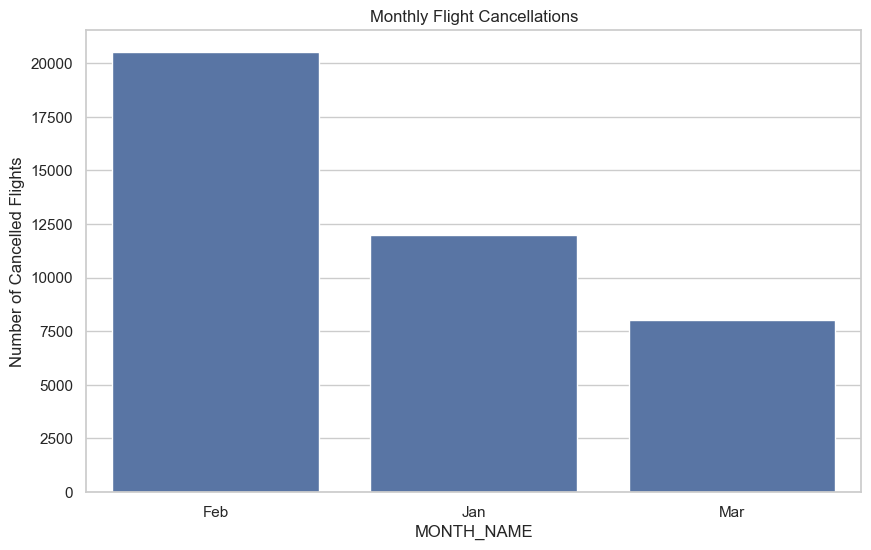

In [39]:
cancel_month = df.groupby('MONTH_NAME')['CANCELLED'].sum()

plt.figure(figsize=(10,6))
sns.barplot(x=cancel_month.index, y=cancel_month.values)
plt.title("Monthly Flight Cancellations")
plt.ylabel("Number of Cancelled Flights")
plt.show()

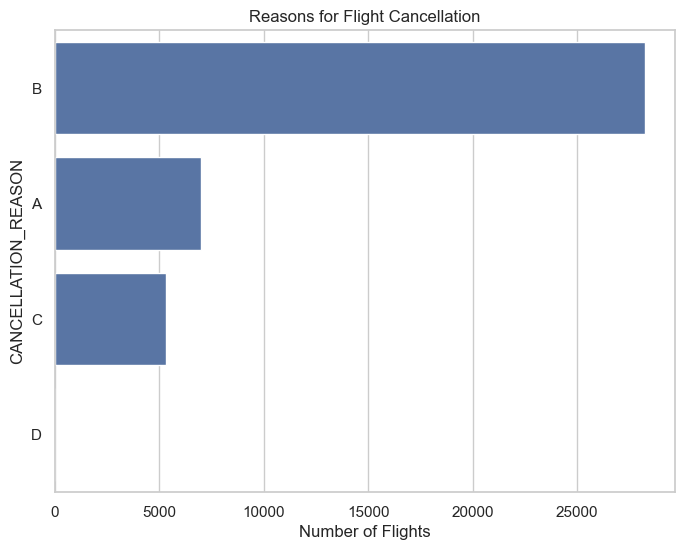

In [40]:
cancel_reason = df[df['CANCELLED']==1]['CANCELLATION_REASON'].value_counts()

plt.figure(figsize=(8,6))
sns.barplot(x=cancel_reason.values, y=cancel_reason.index)
plt.title("Reasons for Flight Cancellation")
plt.xlabel("Number of Flights")
plt.show()

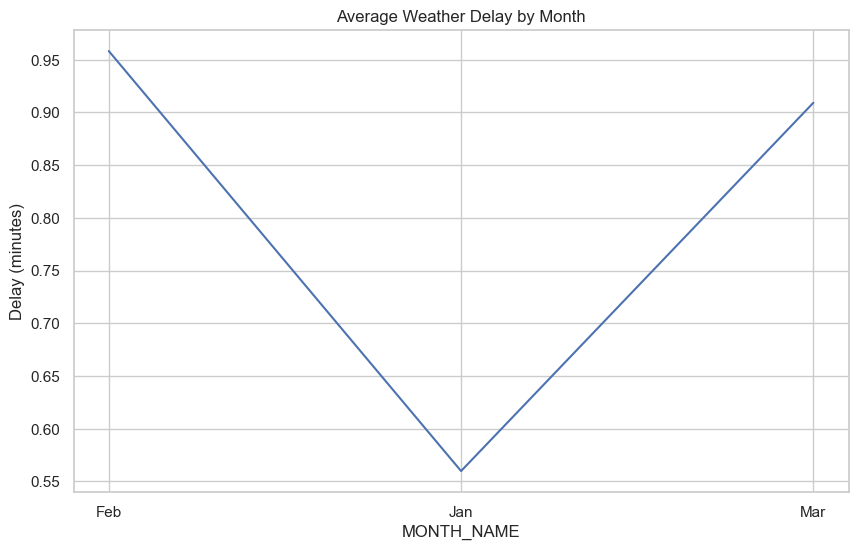

In [41]:
weather_delay = df.groupby('MONTH_NAME')['WEATHER_DELAY'].mean()

plt.figure(figsize=(10,6))
sns.lineplot(x=weather_delay.index, y=weather_delay.values)
plt.title("Average Weather Delay by Month")
plt.ylabel("Delay (minutes)")
plt.show()